# FriendsCast Detection (YOLOv8) — Training Notebook

**Goal:** Detect and identify the 6 main Friends actors using **YOLOv8** (object detection + multi-class classification).

**Classes (6):**
- courteney_cox
- david_schwimmer
- jennifer_aniston
- lisa_kudrow
- matt_leblanc
- matthew_perry

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os, glob, shutil, random
from pathlib import Path
import yaml
import pandas as pd

## 1) Data sources

We use:
- **Raw images** collected from Google Images (6 folders, one per actor)
- **Bounding-box annotations** created with MakeSense.ai (YOLO format)

This notebook rebuilds a clean YOLO dataset with train/val/test splits and trains YOLOv8 by transfer learning.

In [7]:
IMAGES_ROOT = "/content/drive/MyDrive/Friends"          # raw images
LABELS_ROOT = "/content/drive/MyDrive/Friends_YOLO"     # labels .txt
OUT_ROOT = "/content/friends_dataset"                  # final dataset

print(" IMAGES_ROOT exists:", os.path.exists(IMAGES_ROOT))
print(" LABELS_ROOT exists:", os.path.exists(LABELS_ROOT))

 IMAGES_ROOT exists: False
 LABELS_ROOT exists: False


In [8]:
# counts per class

for folder in sorted(os.listdir(IMAGES_ROOT)):
    p = os.path.join(IMAGES_ROOT, folder)
    if os.path.isdir(p):
        imgs = [f for f in os.listdir(p) if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]
        print(f"{folder}: {len(imgs)} images")

Courteney Cox: 48 images
David Schwimmer: 45 images
Jennifer Aniston: 42 images
Lisa Kudrow: 46 images
Matt LeBlanc: 47 images
Matthew Perry: 49 images


## 2) Classes

We keep a stable class order (important for YOLO ids):

0. courteney_cox  
1. david_schwimmer  
2. jennifer_aniston  
3. lisa_kudrow  
4. matt_leblanc  
5. matthew_perry  

In [9]:
# clean output folder
if os.path.exists(OUT_ROOT):
    shutil.rmtree(OUT_ROOT)

splits = {"train": 0.7, "val": 0.2, "test": 0.1}
for s in splits:
    os.makedirs(f"{OUT_ROOT}/images/{s}", exist_ok=True)
    os.makedirs(f"{OUT_ROOT}/labels/{s}", exist_ok=True)

def find_image_by_stem(stem: str):
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        p = glob.glob(os.path.join(IMAGES_ROOT, "*", stem + ext))
        if p:
            return p[0]
    return None

labels = sorted(glob.glob(os.path.join(LABELS_ROOT, "*.txt")))

pairs = []
missing_img = 0
for lp in labels:
    stem = Path(lp).stem
    img = find_image_by_stem(stem)
    if img is None:
        missing_img += 1
        continue
    pairs.append((img, lp))

print(" Pairs found:", len(pairs))
print("⚠️ Missing images:", missing_img)

random.seed(42)
random.shuffle(pairs)

n = len(pairs)
n_train = int(splits["train"] * n)
n_val = int(splits["val"] * n)

split_data = {
    "train": pairs[:n_train],
    "val": pairs[n_train:n_train+n_val],
    "test": pairs[n_train+n_val:],
}

for s, items in split_data.items():
    for img, lab in items:
        shutil.copy2(img, f"{OUT_ROOT}/images/{s}/{Path(img).name}")
        shutil.copy2(lab, f"{OUT_ROOT}/labels/{s}/{Path(lab).name}")

for s in splits:
    print(s, "-> images:", len(os.listdir(f"{OUT_ROOT}/images/{s}")),
              "| labels:", len(os.listdir(f"{OUT_ROOT}/labels/{s}")))

 Pairs found: 277
⚠️ Missing images: 0
train -> images: 193 | labels: 193
val -> images: 55 | labels: 55
test -> images: 29 | labels: 29


In [10]:
# Create YAML

names = {
    0: "courteney_cox",
    1: "david_schwimmer",
    2: "jennifer_aniston",
    3: "lisa_kudrow",
    4: "matt_leblanc",
    5: "matthew_perry",
}

data = {
    "path": OUT_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names
}

yaml_path = f"{OUT_ROOT}/friends.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("✅ YAML:", yaml_path)
print(open(yaml_path).read())

✅ YAML: /content/friends_dataset/friends.yaml
path: /content/friends_dataset
train: images/train
val: images/val
test: images/test
names:
  0: courteney_cox
  1: david_schwimmer
  2: jennifer_aniston
  3: lisa_kudrow
  4: matt_leblanc
  5: matthew_perry



## 3) Model and training setup

We fine-tune **YOLOv8n** pretrained on COCO.

**Why YOLOv8n?**
- fast training on Colab
- good baseline for a small custom dataset
- strong performance for face/head detection

**Key hyperparameters**
- img size: 640
- epochs: 50
- batch: 16
- optimizer & augmentations: Ultralytics defaults

In [11]:
!pip -q install ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    imgsz=640,
    epochs=50,
    batch=16,
    device=0
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/friends_dataset/friends.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

In [12]:
# Save best weights to Drive
import glob, os, shutil

runs = sorted(glob.glob("runs/detect/train*"), key=os.path.getmtime)
RUN_DIR = runs[-1]
print(" RUN_DIR:", RUN_DIR)

best_pt = os.path.join(RUN_DIR, "weights", "best.pt")
last_pt = os.path.join(RUN_DIR, "weights", "last.pt")

DEST = "/content/drive/MyDrive/Friends_Project_Outputs"
os.makedirs(DEST, exist_ok=True)

shutil.copy2(best_pt, os.path.join(DEST, "best.pt"))
shutil.copy2(last_pt, os.path.join(DEST, "last.pt"))
print(" Weights copied to:", DEST)

 RUN_DIR: runs/detect/train
 Weights copied to: /content/drive/MyDrive/Friends_Project_Outputs


Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


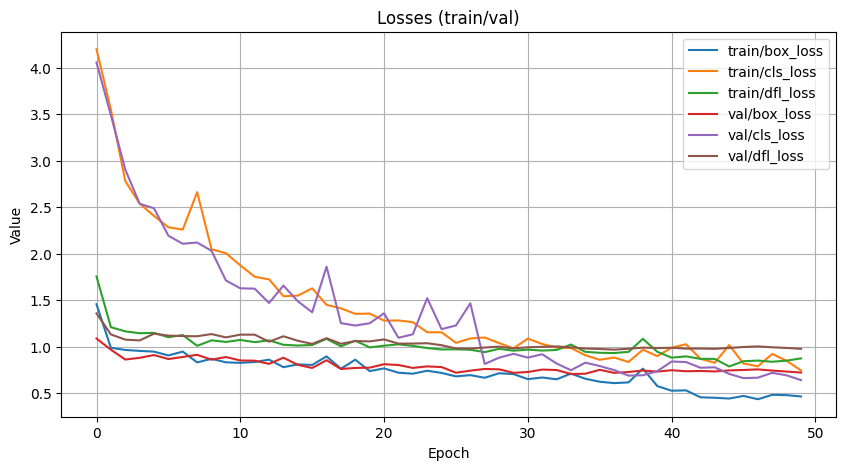

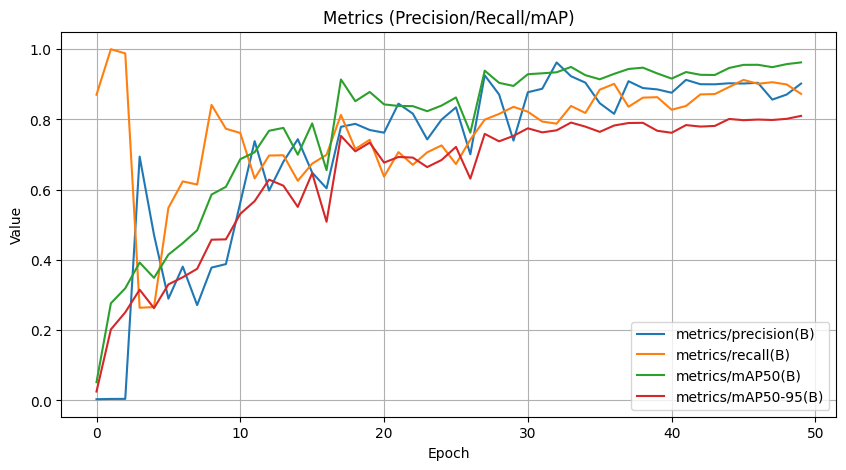

 Export metrics: runs/detect/train/results_full.csv


In [13]:
# Training metrics & plots

import pandas as pd, os
import matplotlib.pyplot as plt

csv_path = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
print("Columns:", list(df.columns))

# losses
loss_cols = [c for c in df.columns if "loss" in c.lower()]
plt.figure(figsize=(10,5))
for c in loss_cols:
    plt.plot(df[c], label=c)
plt.title("Losses (train/val)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# metrics
metric_cols = [c for c in df.columns if any(k in c.lower() for k in ["precision", "recall", "map50", "map"])]
plt.figure(figsize=(10,5))
for c in metric_cols:
    plt.plot(df[c], label=c)
plt.title("Metrics (Precision/Recall/mAP)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# export full metrics
out_csv = os.path.join(RUN_DIR, "results_full.csv")
df.to_csv(out_csv, index=False)
print(" Export metrics:", out_csv)

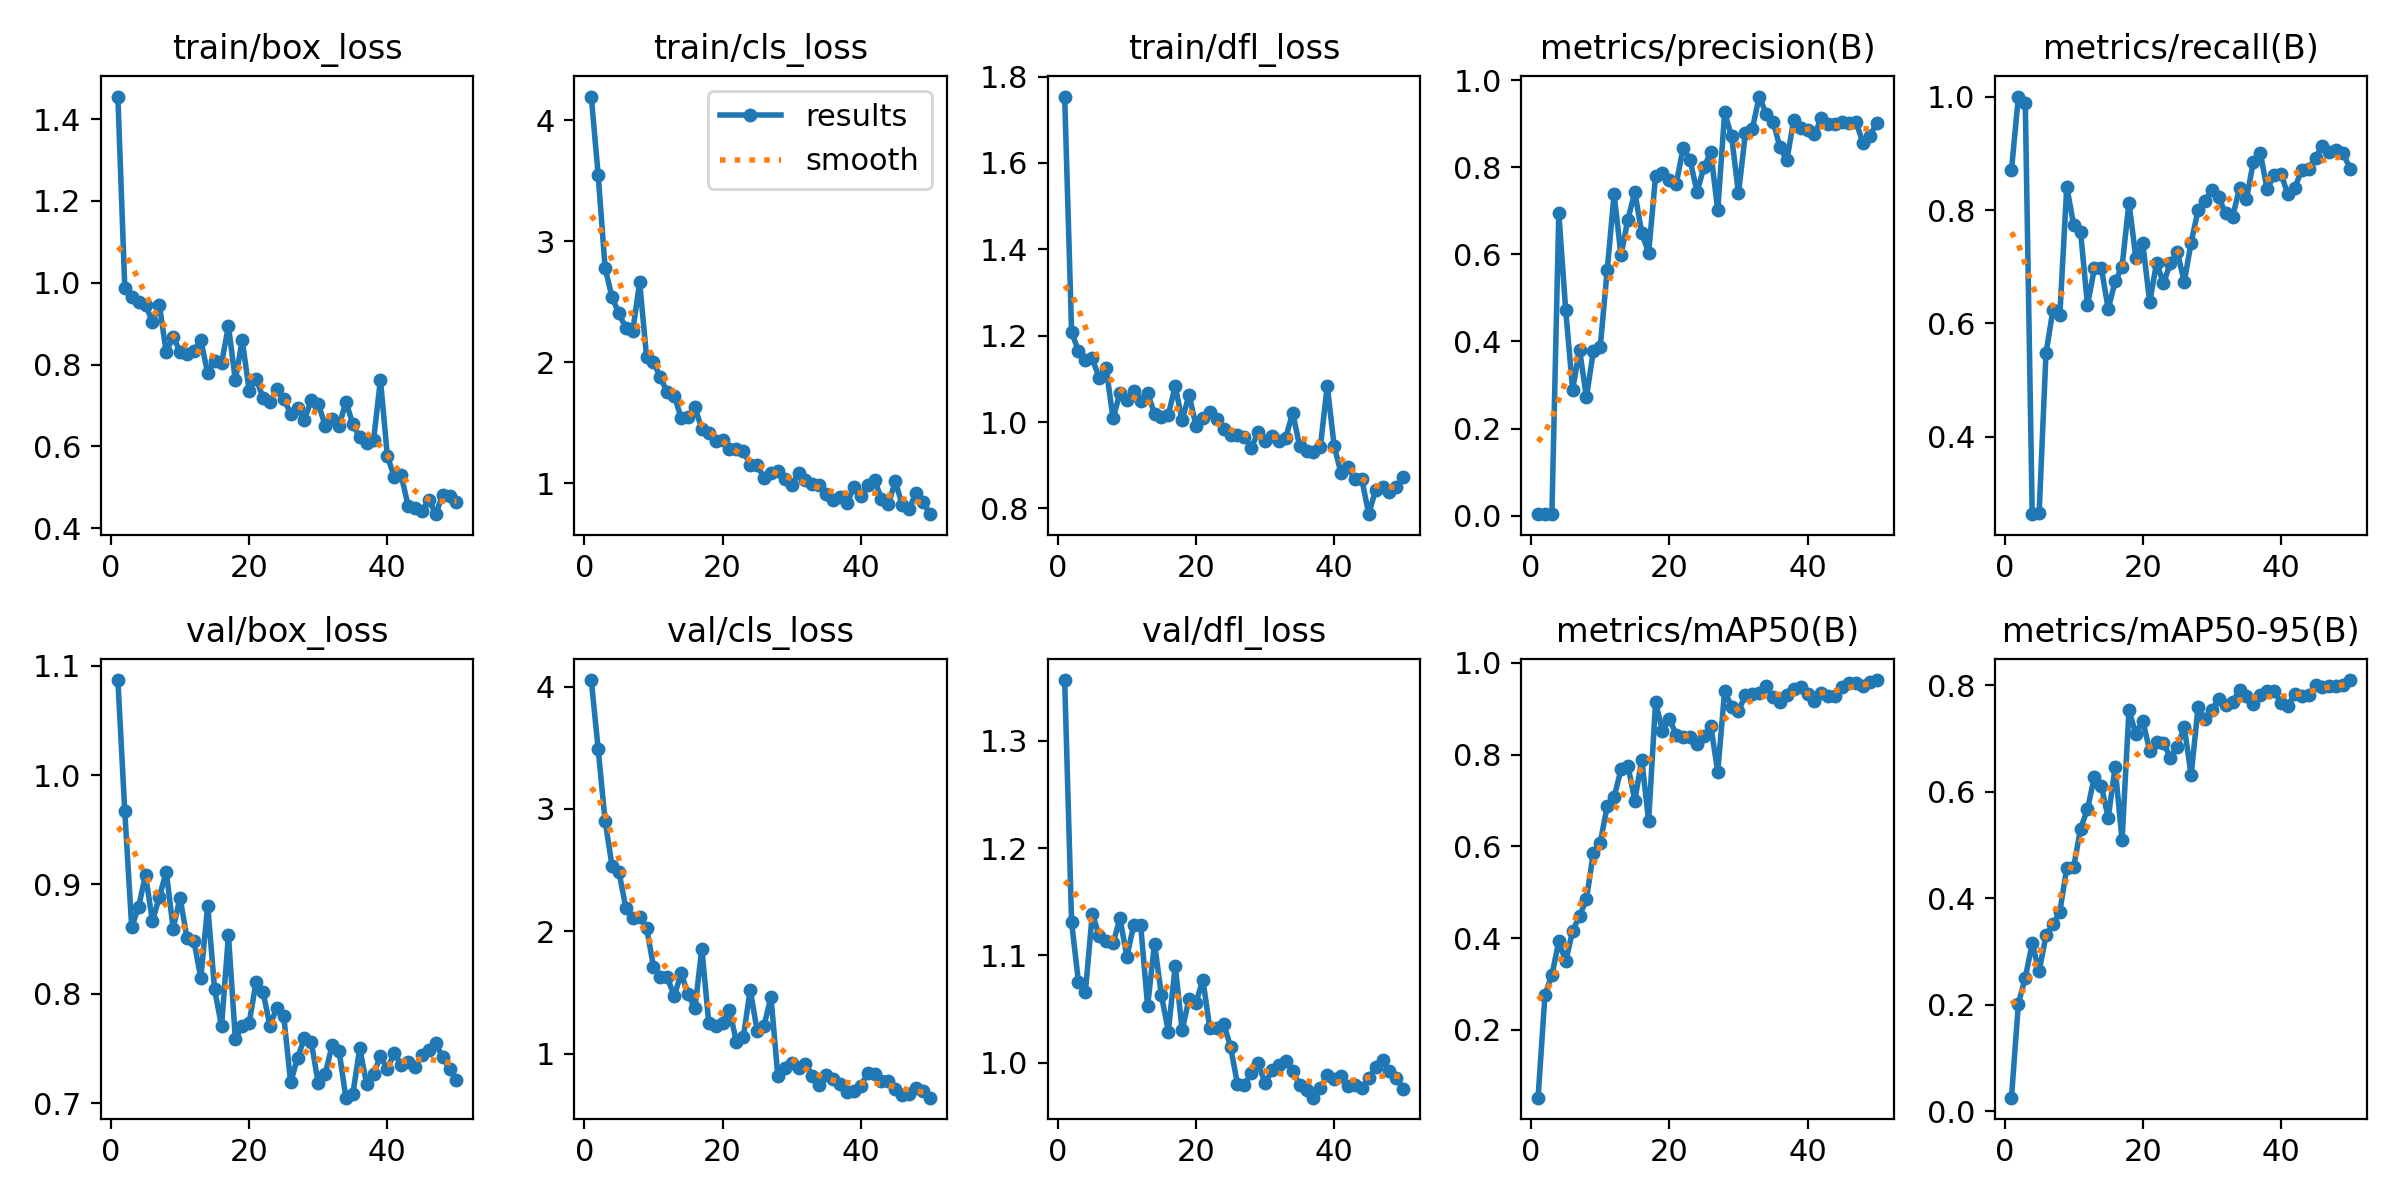

Absent: PR_curve.png
Absent: F1_curve.png
Absent: P_curve.png
Absent: R_curve.png


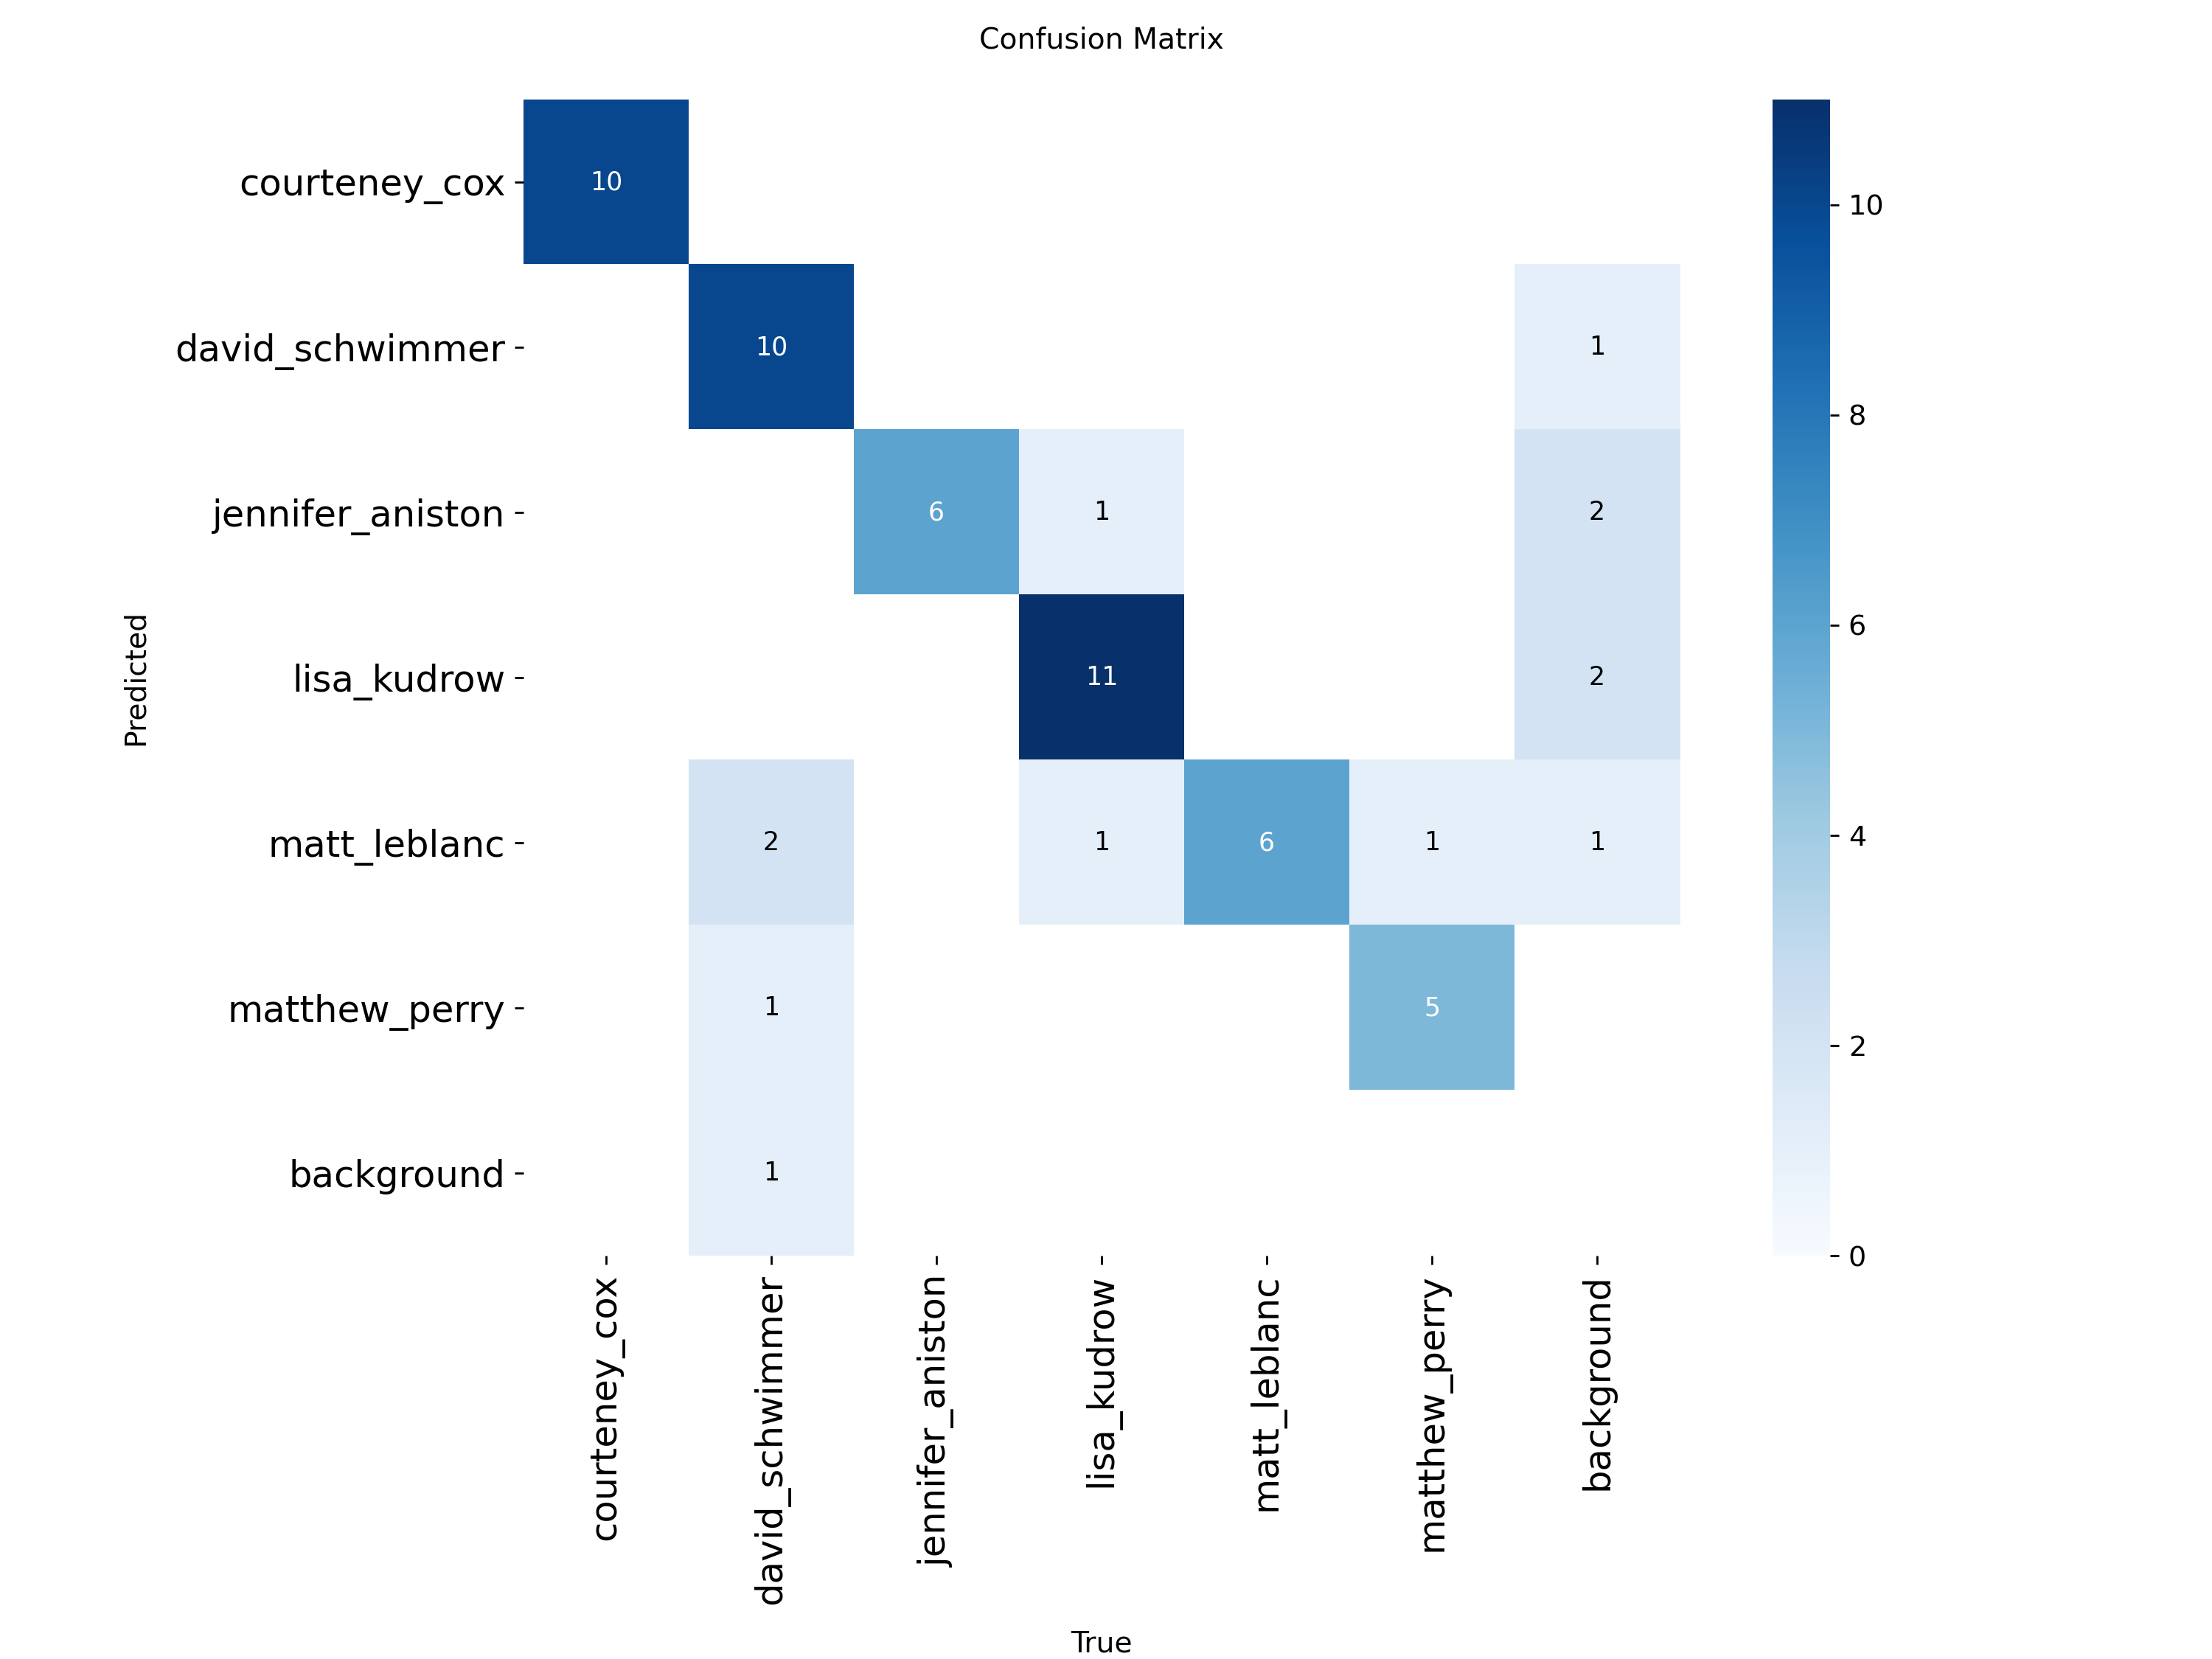

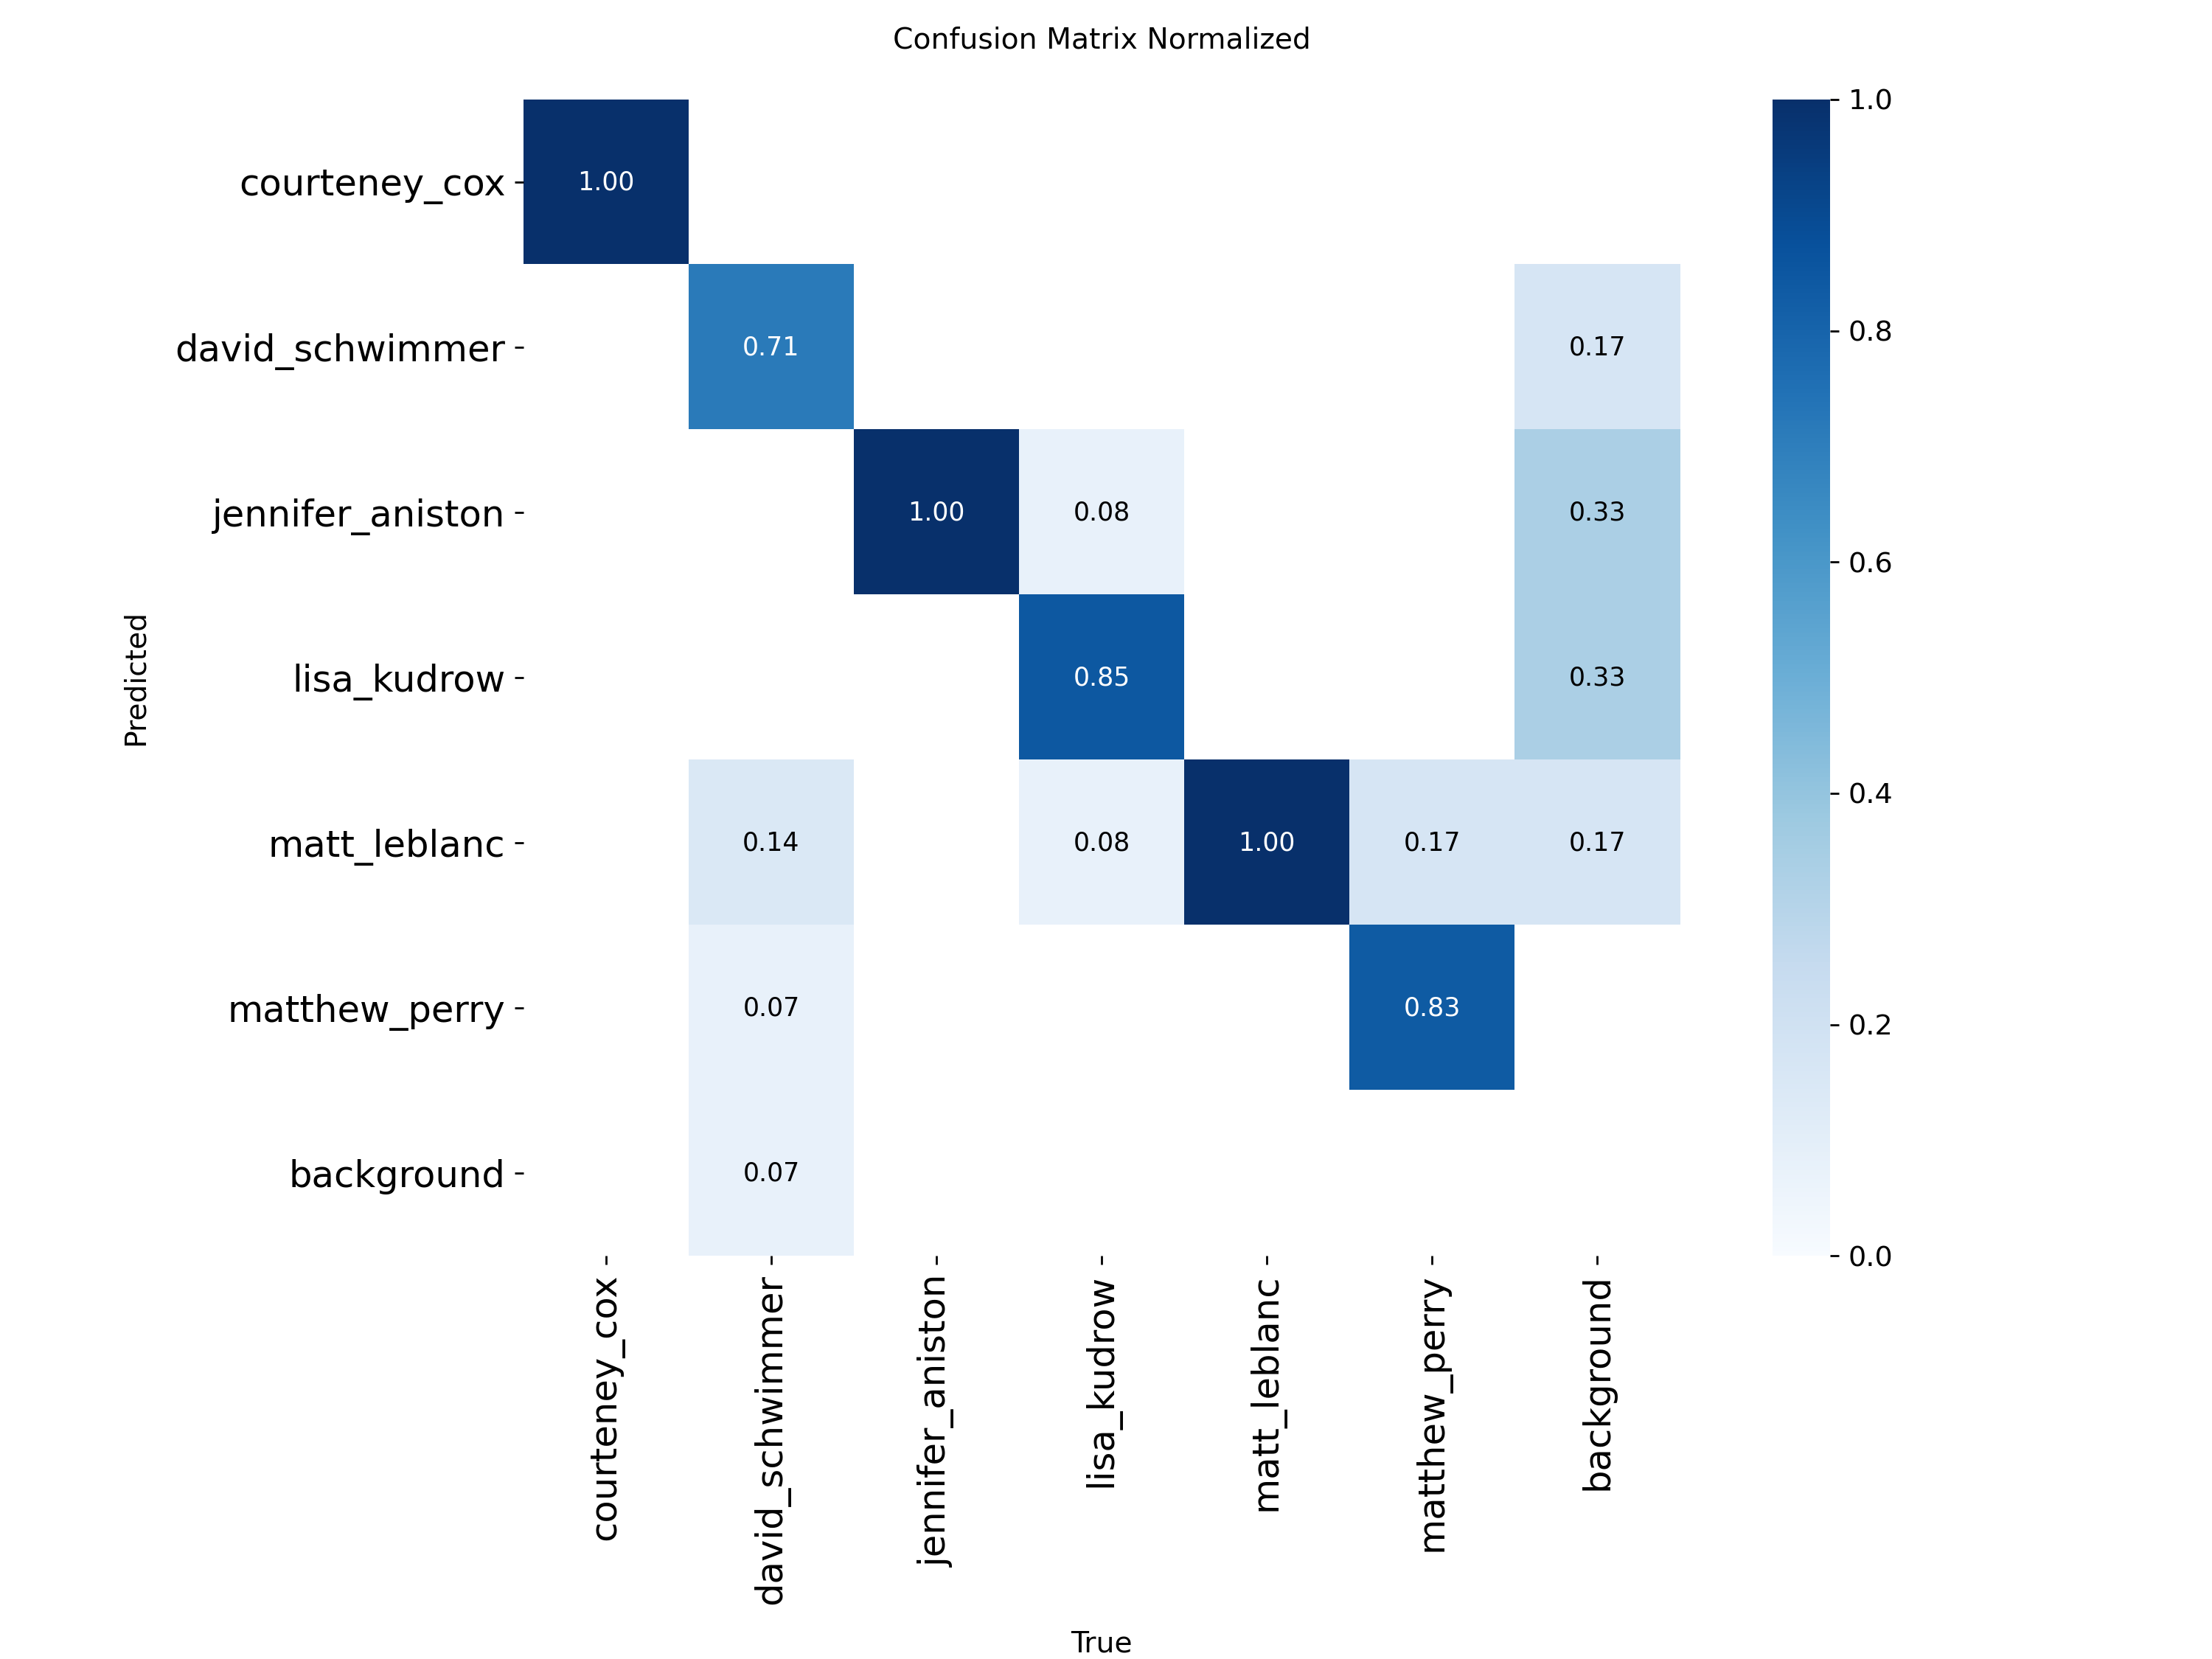

In [14]:
# Visualize YOLO auto-generated plots

from PIL import Image
import os

auto_plots = [
    "results.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]

for p in auto_plots:
    fp = os.path.join(RUN_DIR, p)
    if os.path.exists(fp):
        display(Image.open(fp))
    else:
        print("Absent:", p)

## 4) Next step

In the next notebook (**Test/Evaluation notebook**), we:
- load `best.pt`
- evaluate on the test split
- compute final metrics
- show qualitative results (good predictions + common errors)